# Yelp Business Listings Data Quality Audit

Audit of a large Yelp business listings dataset (1M records) focused on identifying data quality issues that distort category and geographic analysis.

## Goal
Identify data quality issues that can mislead business comparisons.

## Dataset
Large U.S. business listings dataset with 1,000,000 records.

## Key Data Quality Issues
- `Rating = 0` is used as a placeholder for unrated businesses
- Invalid values appear in the `State` column
- Raw category averages are distorted if unrated businesses are included

## Cleaning Approach
- Created `is_rated` flag
- Created `valid_state` flag
- Built rated-only and valid-state subsets for safer analysis

## Business Impact
Without cleaning, category and geographic comparisons can lead to false conclusions.
After filtering placeholder ratings and invalid state values, the dataset becomes more reliable for benchmarking and decision-making.

## Key Findings
- 259,645 records were unrated placeholders
- 4,042 records had invalid state values
- Category averages changed significantly after filtering
- Geographic analysis required validation of state values

## Tech Stack
- Python
- pandas
- matplotlib

In [1]:
import pandas as pd

df = pd.read_csv("data/yelp_database.csv", low_memory=False, dtype={"Phone": "string", "OLF": "string"})
df.head()

,ID,Time_GMT,Phone,Organization,OLF,Rating,NumberReview,Category,Country,CountryCode,State,City,Street,Building
0,1,3/12/2021 2:10,12562343500,The Station's Best,<NA>,4.0,4,Delivery,USA,US,AL,Alexander City,Jefferson,977
1,2,3/12/2021 2:10,12566758004,Pizza Hut,<NA>,3.0,6,Delivery,USA,US,AL,Alexander City,4581 Hwy,4581
2,3,3/12/2021 2:10,12562342181,Zaxby's Chicken Fingers & Buffalo Wings,<NA>,3.0,13,Delivery,USA,US,AL,Alexander City,4497 Highway,4497
3,4,3/12/2021 2:10,12564097272,Papa John's Pizza,<NA>,1.0,1,Delivery,USA,US,AL,Alexander City,2064 Cherokee,2064
4,5,3/12/2021 2:10,12562155510,Arby's,<NA>,2.0,7,Delivery,USA,US,AL,Alexander City,2593 Hwy,2593


In [2]:
df.shape


(1000000, 14)

In [3]:
df.isnull().sum()



ID                   0
Time_GMT             0
Phone                0
Organization       469
OLF             961890
Rating               0
NumberReview         0
Category             0
Country              0
CountryCode          0
State             1058
City               469
Street          159615
Building        157941
dtype: int64

In [4]:
df.duplicated().sum()


np.int64(0)

In [5]:
df["Country"].value_counts().head(10)


Country
USA    1000000
Name: count, dtype: int64

In [6]:
df["Category"].value_counts().head(10)


Category
Plumbing                      510305
Delivery                      348522
Air Conditioning & Heating    141173
Name: count, dtype: int64

In [7]:
df["Rating"].describe()


count    1000000.000000
mean           2.784374
std            1.914260
min            0.000000
25%            0.000000
50%            3.500000
75%            4.500000
max            5.000000
Name: Rating, dtype: float64

In [8]:
df["NumberReview"].describe()

count    1000000.000000
mean          56.685617
std          185.571194
min            0.000000
25%            0.000000
50%            4.000000
75%           35.000000
max        12570.000000
Name: NumberReview, dtype: float64

In [9]:
df[df["Rating"] == 0][["Rating", "NumberReview"]].head(20)

,Rating,NumberReview
348522,0.0,0
348523,0.0,0
348524,0.0,0
348525,0.0,0
348526,0.0,0
348527,0.0,0
348528,0.0,0
348529,0.0,0
348530,0.0,0
348531,0.0,0


In [10]:
df[df["Rating"] == 0]["NumberReview"].describe()

count    259645.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: NumberReview, dtype: float64

In [11]:
df[(df["Rating"] == 0) & (df["NumberReview"] == 0)].shape

(259645, 14)

In [12]:
df[df["Rating"] > 0]["Rating"].describe()

count    740355.000000
mean          3.760863
std           1.130070
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: Rating, dtype: float64

In [13]:
df[df["Rating"] > 0]["Rating"].value_counts().sort_index()

Rating
1.0     41532
1.5     11421
2.0     28741
2.5     49235
3.0     77447
3.5    108196
4.0    131649
4.5    106304
5.0    185830
Name: count, dtype: int64

In [14]:
df[df["Rating"] > 0].groupby("Rating")["NumberReview"].mean()

Rating
1.0      2.084585
1.5     22.724543
2.0     29.637765
2.5     35.319062
3.0     52.199711
3.5     96.932733
4.0    169.227165
4.5    126.658818
5.0     18.701926
Name: NumberReview, dtype: float64

In [15]:
df[df["Rating"] > 0].groupby("Rating")["NumberReview"].median()

Rating
1.0     1.0
1.5    10.0
2.0    11.0
2.5    12.0
3.0    16.0
3.5    31.0
4.0    56.0
4.5    37.0
5.0     2.0
Name: NumberReview, dtype: float64

In [16]:
df[df["Rating"] > 0]["Rating"].value_counts().sort_index()

Rating
1.0     41532
1.5     11421
2.0     28741
2.5     49235
3.0     77447
3.5    108196
4.0    131649
4.5    106304
5.0    185830
Name: count, dtype: int64

In [17]:
df.groupby("Category")[["Rating", "NumberReview"]].mean()

,Rating,NumberReview
Category,,
Air Conditioning & Heating,3.129384,18.799678
Delivery,3.553991,139.859989
Plumbing,2.163305,10.361111


In [18]:
df[df["Rating"] > 0].groupby("Category")[["Rating", "NumberReview"]].mean()

,Rating,NumberReview
Category,,
Air Conditioning & Heating,3.988233,23.959186
Delivery,3.553991,139.859989
Plumbing,3.927779,18.812027


In [19]:
df["State"].value_counts().head(10)

State
CA    164496
NY     79875
MA     67328
IL     57040
FL     47752
NJ     43228
PA     40890
OH     38191
CT     30084
TX     27685
Name: count, dtype: int64

In [20]:
df["City"].value_counts().head(10)

City
Los Angeles      13423
Chicago          11730
New York          9353
Brooklyn          8338
Boston            5495
Oklahoma City     4639
Phoenix           4628
Philadelphia      4572
San Jose          4475
Denver            4436
Name: count, dtype: int64

In [21]:
df.groupby("State")[["NumberReview"]].mean().sort_values("NumberReview", ascending=False).head(10)

,NumberReview
State,
CA,156.767678
DC,147.542812
NV,146.959227
Fort,137.000000
HI,121.824134
WA,114.125834
AZ,92.791423
TX,74.860755
OR,69.293629


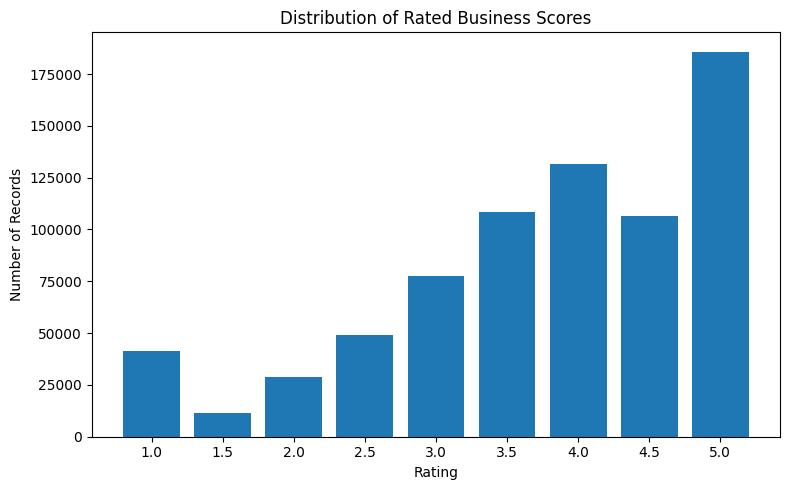

In [22]:
import matplotlib.pyplot as plt

rating_counts = df[df["Rating"] > 0]["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Distribution of Rated Business Scores")
plt.xlabel("Rating")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Chart 1. Distribution of Rated Business Scores

This chart shows the distribution of business ratings after excluding unrated records (`Rating = 0`).
The chart confirms that high ratings are common among rated businesses, with 5.0 appearing most frequently.

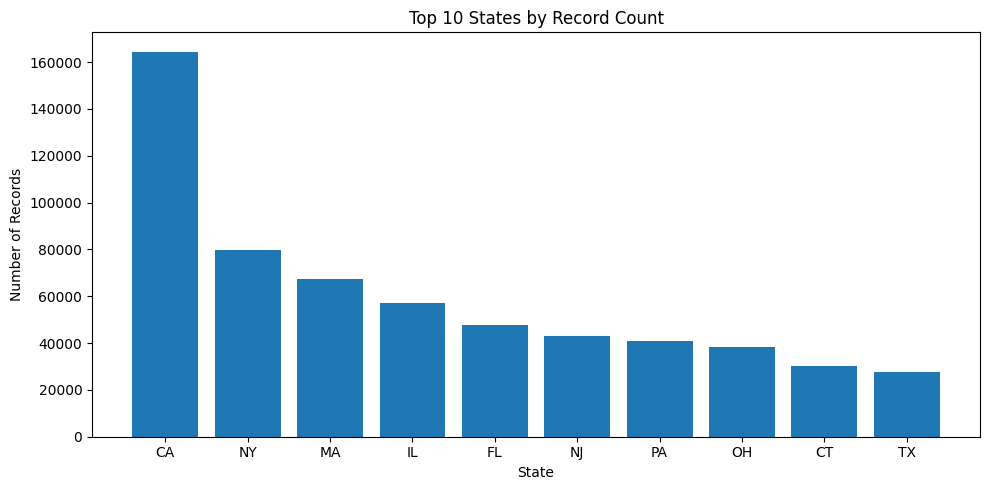

In [23]:
top_states = df["State"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_states.index, top_states.values)
plt.title("Top 10 States by Record Count")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Chart 2. Top 10 States by Record Count

This chart highlights the geographic concentration of records across U.S. states.
The dataset is not evenly distributed across the United States. California contains the highest number of records by a wide margin.

## Findings

- The dataset contains 1,000,000 records and 14 columns.
- All records belong to the United States.
- The dataset includes three business categories: Plumbing, Delivery, and Air Conditioning & Heating.
- No exact duplicate rows were found.
- The `NumberReview` column is highly skewed: many businesses have very few reviews, while a small number of records have extremely high review counts.
- The `Rating` column contains 259,645 zero values, and all of them are paired with `NumberReview = 0`. This strongly suggests that `Rating = 0` is used as a placeholder for unrated businesses rather than a true customer rating.
- After excluding unrated businesses (`Rating = 0`), the remaining 740,355 records show generally positive customer ratings. The average rating is 3.76, the median is 4.0, and the most frequent rating is 5.0.
- Review volume does not increase linearly with rating. Businesses rated 4.0 have the highest typical review volume, while many businesses rated 5.0 have very few reviews (median = 2). This suggests that perfect ratings are often based on limited review counts.
- Category-level averages are strongly affected by unrated records. In Plumbing and Air Conditioning & Heating, raw average ratings are heavily reduced by `Rating = 0` placeholders, while Delivery remains unchanged after filtering. This means category comparisons should be based on rated records only.
- Delivery businesses have a much higher average review volume than the other two categories. After excluding unrated records, Delivery averages 139.86 reviews per business, compared with 23.96 for Air Conditioning & Heating and 18.81 for Plumbing.
- The dataset is geographically concentrated in a limited number of U.S. states, with California clearly dominating the record count, followed by New York, Massachusetts, and Illinois.
- Geographic fields contain at least some data quality issues. For example, `Fort` appears in the `State` column even though it does not match a standard U.S. state code, suggesting that some location values may be misassigned.
- Average review volume also varies by state. California, Washington D.C., and Nevada appear among the highest-ranking locations in terms of average review count per record.

## Limitations

- The dataset does not represent all Yelp businesses or all business categories.
- All records belong to the United States, and the data is concentrated in a limited number of states and cities.
- `Rating = 0` is used as a placeholder for unrated businesses and should not be interpreted as a true customer rating.
- Some location values appear inconsistent, which may affect geographic analysis.
- The dataset structure supports business-listing analysis, but it does not include full review text or user-level behavioral data.

## Conclusion

This project shows that the dataset is large, structurally useful, and suitable for exploratory analysis, but careful interpretation is necessary. In particular, placeholder values such as `Rating = 0` and inconsistent geographic entries can significantly affect conclusions if they are not identified early. After identifying and interpreting these issues correctly, the dataset provides meaningful insights into ratings, review volume, category differences, and geographic concentration.

## 2. Data Cleaning Rules

This cleaning step prepares the dataset for reliable category and geographic analysis.

Rules applied:
1. `Rating = 0` is treated as a placeholder for unrated businesses, not a true customer rating.
2. A new flag `is_rated` is created to separate rated from unrated records.
3. State values are validated against standard U.S. state codes plus `DC`.
4. Invalid state values are flagged as `valid_state = False`.
5. Geographic summaries use only records with valid state values.
6. Rating-based comparisons use only records with `is_rated = True`.

In [24]:
import pandas as pd

df = pd.read_csv(
    "data/yelp_database.csv",
    low_memory=False,
    dtype={"Phone": "string", "OLF": "string"}
)

df.head()

,ID,Time_GMT,Phone,Organization,OLF,Rating,NumberReview,Category,Country,CountryCode,State,City,Street,Building
0,1,3/12/2021 2:10,12562343500,The Station's Best,<NA>,4.0,4,Delivery,USA,US,AL,Alexander City,Jefferson,977
1,2,3/12/2021 2:10,12566758004,Pizza Hut,<NA>,3.0,6,Delivery,USA,US,AL,Alexander City,4581 Hwy,4581
2,3,3/12/2021 2:10,12562342181,Zaxby's Chicken Fingers & Buffalo Wings,<NA>,3.0,13,Delivery,USA,US,AL,Alexander City,4497 Highway,4497
3,4,3/12/2021 2:10,12564097272,Papa John's Pizza,<NA>,1.0,1,Delivery,USA,US,AL,Alexander City,2064 Cherokee,2064
4,5,3/12/2021 2:10,12562155510,Arby's,<NA>,2.0,7,Delivery,USA,US,AL,Alexander City,2593 Hwy,2593


In [25]:
type(df), df.shape

(pandas.core.frame.DataFrame, (1000000, 14))

In [26]:
df_clean = df.copy()
df_clean.shape

(1000000, 14)

In [27]:
valid_states = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"
}

len(valid_states)

51

In [28]:
df_clean.columns.tolist()

['ID',
 'Time_GMT',
 'Phone',
 'Organization',
 'OLF',
 'Rating',
 'NumberReview',
 'Category',
 'Country',
 'CountryCode',
 'State',
 'City',
 'Street',
 'Building']

In [29]:
df_clean["is_rated"] = df_clean["Rating"] > 0
df_clean["is_rated"].value_counts(dropna=False)

is_rated
True     740355
False    259645
Name: count, dtype: int64

In [30]:
df_clean["valid_state"] = df_clean["State"].isin(valid_states)
df_clean["valid_state"].value_counts(dropna=False)

valid_state
True     995958
False      4042
Name: count, dtype: int64

In [31]:
df_rated = df_clean[df_clean["is_rated"]].copy()
df_geo = df_clean[df_clean["valid_state"]].copy()

df_rated.shape, df_geo.shape

((740355, 16), (995958, 16))

In [32]:
validation_summary = pd.DataFrame({
    "check": [
        "raw_rows",
        "clean_rows",
        "rated_rows",
        "unrated_rows",
        "invalid_state_rows",
        "duplicates_raw",
        "duplicates_clean",
        "min_rating_in_rated",
        "max_rating_in_rated"
    ],
    "value": [
        len(df),
        len(df_clean),
        len(df_rated),
        (~df_clean["is_rated"]).sum(),
        (~df_clean["valid_state"]).sum(),
        df.duplicated().sum(),
        df_clean.duplicated().sum(),
        df_rated["Rating"].min(),
        df_rated["Rating"].max()
    ]
})

validation_summary

,check,value
0,raw_rows,1000000.0
1,clean_rows,1000000.0
2,rated_rows,740355.0
3,unrated_rows,259645.0
4,invalid_state_rows,4042.0
5,duplicates_raw,0.0
6,duplicates_clean,0.0
7,min_rating_in_rated,1.0
8,max_rating_in_rated,5.0


In [33]:
df_clean.loc[~df_clean["valid_state"], "State"].value_counts().head(20)

State
ON          1893
BC           314
BCN          154
NB           118
TAM          107
QC            62
SON           42
CHH           16
Westport      14
COA           13
Kells         10
DEV           10
QLD            9
ERY            8
SCB            8
VIC            8
XGL            8
NLE            8
STS            8
G              7
Name: count, dtype: int64

In [34]:
category_compare = (
    df.groupby("Category")[["Rating", "NumberReview"]].mean()
    .rename(columns={
        "Rating": "raw_avg_rating",
        "NumberReview": "raw_avg_reviews"
    })
    .join(
        df_rated.groupby("Category")[["Rating", "NumberReview"]].mean()
        .rename(columns={
            "Rating": "rated_avg_rating",
            "NumberReview": "rated_avg_reviews"
        })
    )
)

category_compare

,raw_avg_rating,raw_avg_reviews,rated_avg_rating,rated_avg_reviews
Category,,,,
Air Conditioning & Heating,3.129384,18.799678,3.988233,23.959186
Delivery,3.553991,139.859989,3.553991,139.859989
Plumbing,2.163305,10.361111,3.927779,18.812027


In [35]:
top_states_clean = df_geo["State"].value_counts().head(10)
top_states_clean

State
CA    164496
NY     79875
MA     67328
IL     57040
FL     47752
NJ     43228
PA     40890
OH     38191
CT     30084
TX     27685
Name: count, dtype: int64

df_clean.to_csv("data/yelp_clean.csv", index=False)
df_rated.to_csv("data/yelp_rated_only.csv", index=False)

In [ ]:
## Conclusion

The audit reveals that raw Yelp business listing data can lead to misleading conclusions if placeholder ratings and invalid location values are not handled properly.

After filtering unrated businesses and validating geographic data, the dataset becomes reliable for category and regional comparisons.

In [ ]:
This improves the quality of business insights and prevents incorrect decision-making based on flawed data.